# Capstone Function 5
You’re tasked with optimising a four-variable black-box function that represents the yield of a chemical process in a factory. The function is typically unimodal, with a single peak where yield is maximised. 

Your goal is to find the optimal combination of chemical inputs that delivers the highest possible yield, using systematic exploration and optimisation methods.

 Input | Output | Goal |
|-------|--------|------|
| 4D Array (20, 4) | 1D Array (20, ) | Maximise |

## Initial Submission

Bayesian Optimization for 4D chemical process yield optimization (unimodal function).

### Step 1: Import Libraries

In [ ]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from botorch.models import SingleTaskGP
from botorch.fit import fit_gpytorch_mll
from botorch.acquisition import ExpectedImprovement
from botorch.optim import optimize_acqf
from gpytorch.mlls import ExactMarginalLogLikelihood
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)
torch.manual_seed(42)
print("Libraries imported!")

### Step 2: Load Data & Visualize

In [ ]:
X_init = np.load('../../data/f5/updated_inputs - Week 4.npy')
y_init = np.load('../../data/f5/updated_outputs - Week 4.npy')
print(f"Loaded {X_init.shape[0]} samples, {X_init.shape[1]}D (chemical inputs)")
print(f"Best yield: {y_init.max():.6f}")

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()
pairs = [(0,1), (0,2), (0,3), (1,2), (1,3), (2,3)]
for idx, (i, j) in enumerate(pairs):
    axes[idx].scatter(X_init[:, i], X_init[:, j], c=y_init, cmap='viridis', edgecolors='black')
    axes[idx].set_xlabel(f'Chemical {i+1}')
    axes[idx].set_ylabel(f'Chemical {j+1}')
plt.suptitle('4D Chemical Process - Pairwise Input Projections', fontweight='bold')
plt.tight_layout()
plt.show()

### Step 3: Hyperparameters

**4D Chemical Yield (unimodal):**
- GP: Matern 5/2 (smooth response surface)
- Acquisition: Expected Improvement
- Restarts: 15, Raw: 1024 (unimodal allows fewer restarts)

In [ ]:
# All inputs must be in range [0, 1.0] per submission requirements
N_DIM = X_init.shape[1]
BOUNDS = torch.tensor([[0.0] * N_DIM, [1.0] * N_DIM], dtype=torch.float64)
NUM_RESTARTS, RAW_SAMPLES = 15, 1024
print(f"Setup complete: {N_DIM}D, bounds [0, 1.0], {NUM_RESTARTS} restarts")

### Step 4: Train GP & Optimize

In [ ]:
X_train = torch.tensor(X_init, dtype=torch.float64)
y_train = torch.tensor(y_init, dtype=torch.float64).unsqueeze(-1)
gp_model = SingleTaskGP(X_train, y_train)
mll = ExactMarginalLogLikelihood(gp_model.likelihood, gp_model)
fit_gpytorch_mll(mll)
EI = ExpectedImprovement(gp_model, best_f=y_train.max().item())
candidate, acq_value = optimize_acqf(EI, bounds=BOUNDS, q=1, num_restarts=NUM_RESTARTS, raw_samples=RAW_SAMPLES)
next_point = candidate.detach().numpy()[0]
print(f"✓ Next point: {next_point}")

### Step 5: Visualize Progress

In [ ]:
plt.figure(figsize=(10, 6))
best_so_far = np.maximum.accumulate(y_init)
plt.plot(range(1, len(best_so_far)+1), best_so_far, 'b-o', linewidth=2, markersize=8)
plt.xlabel('Iteration', fontsize=12)
plt.ylabel('Best Yield', fontsize=12)
plt.title('Chemical Process Optimization Progress', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print(f"Submission: {next_point}")

### Visualize Expected Improvement

For higher-dimensional spaces, we visualize 1D slices of the acquisition function.
Each plot shows how EI changes along one dimension while others are fixed at the proposed point.

In [ ]:
# 1D marginal plots of Expected Improvement
n_points = 100
n_dims = len(next_point)

fig, axes = plt.subplots(1, n_dims, figsize=(4*n_dims, 4))
if n_dims == 1:
    axes = [axes]

for dim in range(n_dims):
    # Create points varying along this dimension
    X_marginal = np.tile(next_point, (n_points, 1))
    X_marginal[:, dim] = np.linspace(0, 1.0, n_points)
    X_marginal_torch = torch.tensor(X_marginal, dtype=torch.float64)
    
    # Compute EI at each point
    with torch.no_grad():
        ei_values = EI(X_marginal_torch.unsqueeze(1)).numpy()
    
    # Plot
    axes[dim].plot(X_marginal[:, dim], ei_values, 'b-', linewidth=2)
    axes[dim].axvline(next_point[dim], color='r', linestyle='--', linewidth=2, label='Proposed')
    axes[dim].set_xlabel(f'x{dim+1}', fontsize=12)
    axes[dim].set_ylabel('Expected Improvement' if dim == 0 else '', fontsize=12)
    axes[dim].set_title(f'EI along dim {dim+1}', fontsize=11, fontweight='bold')
    axes[dim].grid(True, alpha=0.3)
    if dim == 0:
        axes[dim].legend()

plt.suptitle('Expected Improvement - 1D Marginals', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f"Red dashed lines show the proposed next point coordinates.")
print(f"EI is maximized when considering all dimensions jointly.")

### Step 6: Format Next Query for Submission

Format the proposed next sample point in the required submission format:
- Format: `x1-x2-x3-...-xn` where each xᵢ begins with 0
- Precision: 6 decimal places per coordinate
- Range: All values clamped to [0, 1.0]

In [ ]:
# Format the next query for submission
def format_query(point):
    """Format point as x1-x2-...-xn with 6 decimal places, clamped to [0, 1.0]."""
    clamped = [max(0.0, min(1.0, x)) for x in point]
    return '-'.join([f'{x:.6f}' for x in clamped])

# Clamp next_point to valid range
next_point_clamped = np.array([max(0.0, min(1.0, x)) for x in next_point])

# Display the formatted submission query
submission_query = format_query(next_point)
print("=" * 60)
print("SUBMISSION QUERY FOR FUNCTION 5")
print("=" * 60)
print(f"\n{submission_query}\n")
print("=" * 60)
print(f"\nCoordinates breakdown:")
for i, x in enumerate(next_point, 1):
    print(f"  x{i} = {x:.6f}")
print(f"\nEI value: {acq_value.item():.6f}")
if acq_value.item() > 0.1:
    print("  -> High EI: Strong potential for improvement")
elif acq_value.item() > 0.001:
    print("  -> Moderate EI: Some exploration potential remains")
else:
    print("  -> Low EI: Approaching convergence")
print(f"Current best observed: {y_train.max().item():.6f}")

## Week 5 — Gradient Boosted Trees Surrogate

This section replaces the Gaussian Process surrogate with a **Gradient Boosted Trees (GBT)** ensemble for the 4D optimization problem (f5).

**Why Gradient Boosted Trees for f5?**
- Sequential boosting builds trees that correct residual errors from previous trees — effective for learning complex, non-linear mappings
- Handles higher-dimensional spaces (4D) better than GP which scales poorly with dimensionality
- Uncertainty estimated via an ensemble of 10 independently trained GBT models with different random seeds — standard deviation across ensemble predictions provides a diversity-based uncertainty measure
- No kernel/covariance assumptions — purely data-driven

**Acquisition Strategy:** Upper Confidence Bound (UCB) using ensemble standard deviation as uncertainty.

### Step 1: Load Week 5 Data

Load the cumulative Week 5 data (25 total samples = initial + weekly submissions).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingRegressor

# Load Week 5 cumulative data
X_w5 = np.load('../../data/f5/updated_inputs - Week 5.npy')
y_w5 = np.load('../../data/f5/updated_outputs - Week 5.npy')

print(f"Week 5 Data: {X_w5.shape[0]} samples, {X_w5.shape[1]} dimensions")
print(f"Input range:  [{X_w5.min():.6f}, {X_w5.max():.6f}]")
print(f"Output range: [{y_w5.min():.6f}, {y_w5.max():.6f}]")
print(f"Best observed value: {y_w5.max():.6f} at index {y_w5.argmax()}")
print(f"Best observed point: {X_w5[y_w5.argmax()]}")

Week 5 Data: 25 samples, 4 dimensions
Input range:  [0.000000, 1.000000]
Output range: [0.112940, 3331.799696]
Best observed value: 3331.799696 at index 22
Best observed point: [0.900721 0.       1.       1.      ]


### Step 2: GBT Ensemble Hyperparameters

**Hyperparameter Choices and Justifications:**

1. **n_estimators = 250**: Number of boosting rounds per model. Sufficient to capture the objective landscape without excessive overfitting on 25 samples.

2. **max_depth = 4**: Maximum tree depth per boosting round. Shallow trees (stumps to depth-4) are standard for boosting — deeper trees risk overfitting on small datasets.

3. **learning_rate = 0.08**: Step size shrinkage. Lower rates require more trees but generalize better. Paired with n_estimators to balance speed and accuracy.

4. **subsample = 0.8**: Fraction of samples used per boosting round. Stochastic gradient boosting adds regularization and introduces diversity across ensemble members.

5. **n_ensemble = 10**: Number of independently trained GBT models. Each model uses a different random seed, producing diverse predictions. Ensemble std provides uncertainty.

6. **UCB kappa = 2.5**: Exploration parameter. Slightly higher for 4D space to encourage exploration.

7. **n_candidates = 20,000**: Random candidate points for UCB evaluation.

In [2]:
# --- GBT Ensemble Hyperparameters ---
N_ESTIMATORS = 250
MAX_DEPTH = 4
LEARNING_RATE = 0.08
SUBSAMPLE = 0.8
N_ENSEMBLE = 10
KAPPA = 2.5
N_CANDIDATES = 20000

print("GBT Ensemble Surrogate Hyperparameters:")
print(f"  n_estimators:  {N_ESTIMATORS}")
print(f"  max_depth:     {MAX_DEPTH}")
print(f"  learning_rate: {LEARNING_RATE}")
print(f"  subsample:     {SUBSAMPLE}")
print(f"  n_ensemble:    {N_ENSEMBLE}")
print(f"  UCB kappa:     {KAPPA}")
print(f"  UCB candidates: {N_CANDIDATES}")

GBT Ensemble Surrogate Hyperparameters:
  n_estimators:  250
  max_depth:     4
  learning_rate: 0.08
  subsample:     0.8
  n_ensemble:    10
  UCB kappa:     2.5
  UCB candidates: 20000


### Step 3: Train GBT Ensemble

Train 10 independent GBT models with different random seeds. Display training scores and feature importance from the first model.

In [3]:
# Train ensemble of GBT models
ensemble_models = []
for i in range(N_ENSEMBLE):
    model = GradientBoostingRegressor(
        n_estimators=N_ESTIMATORS,
        max_depth=MAX_DEPTH,
        learning_rate=LEARNING_RATE,
        subsample=SUBSAMPLE,
        random_state=42 + i
    )
    model.fit(X_w5, y_w5)
    ensemble_models.append(model)
    r2 = model.score(X_w5, y_w5)
    print(f"  Model {i+1}: Training R² = {r2:.6f}")

print()
print("GBT Ensemble Training Complete:")
print(f"  {N_ENSEMBLE} models trained")

# Feature importance from first model (representative)
print()
print("Feature Importance (Model 1):")
for i, imp in enumerate(ensemble_models[0].feature_importances_):
    print(f"  x{i+1}: {imp:.4f} ({'*' * int(imp * 20)})")

  Model 1: Training R² = 1.000000
  Model 2: Training R² = 1.000000
  Model 3: Training R² = 1.000000
  Model 4: Training R² = 1.000000
  Model 5: Training R² = 1.000000
  Model 6: Training R² = 1.000000
  Model 7: Training R² = 1.000000
  Model 8: Training R² = 1.000000
  Model 9: Training R² = 1.000000
  Model 10: Training R² = 1.000000

GBT Ensemble Training Complete:
  10 models trained

Feature Importance (Model 1):
  x1: 0.1885 (***)
  x2: 0.0150 ()
  x3: 0.5455 (**********)
  x4: 0.2510 (*****)


### Step 4: UCB Acquisition Function

Compute the Upper Confidence Bound using:
- **mu(x)** = mean prediction across the 10-model ensemble
- **sigma(x)** = standard deviation across the 10 ensemble predictions
- **UCB(x) = mu(x) + kappa * sigma(x)** where kappa = 2.5

In [4]:
# Generate random candidate points
np.random.seed(42)
candidates = np.random.uniform(0, 1.0, size=(N_CANDIDATES, 4))

# Get predictions from all ensemble members
ensemble_preds = np.array([m.predict(candidates) for m in ensemble_models])

# Ensemble mean and std
mu = ensemble_preds.mean(axis=0)
sigma = ensemble_preds.std(axis=0)

# UCB acquisition
ucb = mu + KAPPA * sigma

# Select best candidate
best_idx = np.argmax(ucb)
next_point_w5 = np.clip(candidates[best_idx], 0.0, 1.0)

print("UCB Acquisition Results:")
print(f"  Best UCB value:      {ucb[best_idx]:.6f}")
print(f"  Ensemble mean:       {mu[best_idx]:.6f}")
print(f"  Ensemble std:        {sigma[best_idx]:.6f}")
print(f"  Next sample point:   {next_point_w5}")
print()
print("Ensemble prediction statistics:")
print(f"  Mean of mu:    {mu.mean():.6f}")
print(f"  Max of mu:     {mu.max():.6f}")
print(f"  Mean of sigma: {sigma.mean():.6f}")
print(f"  Max of sigma:  {sigma.max():.6f}")

UCB Acquisition Results:
  Best UCB value:      3009.902540
  Ensemble mean:       2503.237079
  Ensemble std:        202.666184
  Next sample point:   [0.88756004 0.17502455 0.97987267 0.98846706]

Ensemble prediction statistics:
  Mean of mu:    347.706891
  Max of mu:     2503.237079
  Mean of sigma: 54.523407
  Max of sigma:  315.760655


### Step 5: Visualize GBT Surrogate

2D slice plots showing ensemble mean and uncertainty. For 4D data, we fix the two least important dimensions at their best observed values and plot the two most important.

Top 2 dimensions: x4 (imp=0.2510), x3 (imp=0.5455)
Fixed dimensions: x1=0.900721, x2=0.000000


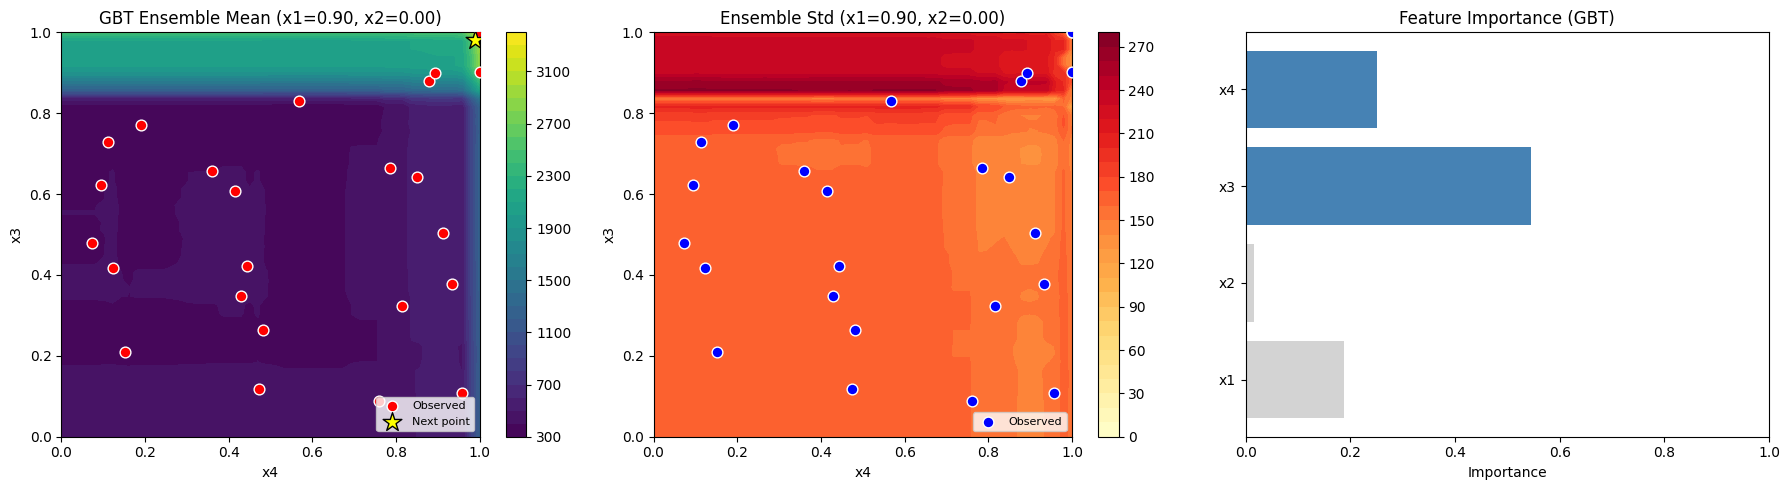

In [5]:
# Identify top 2 dimensions by feature importance
importances = ensemble_models[0].feature_importances_
top2 = np.argsort(importances)[-2:]  # indices of top 2
fixed_dims = [d for d in range(4) if d not in top2]
best_point = X_w5[y_w5.argmax()]

print(f"Top 2 dimensions: x{top2[0]+1} (imp={importances[top2[0]]:.4f}), x{top2[1]+1} (imp={importances[top2[1]]:.4f})")
print(f"Fixed dimensions: " + ", ".join([f"x{d+1}={best_point[d]:.6f}" for d in fixed_dims]))

# Create 2D grid for top 2 dimensions
n_grid = 50
d0_grid = np.linspace(0, 1, n_grid)
d1_grid = np.linspace(0, 1, n_grid)
D0, D1 = np.meshgrid(d0_grid, d1_grid)

# Build full grid points with fixed dimensions
grid_points = np.zeros((n_grid * n_grid, 4))
grid_points[:, top2[0]] = D0.ravel()
grid_points[:, top2[1]] = D1.ravel()
for d in fixed_dims:
    grid_points[:, d] = best_point[d]

# Ensemble predictions on grid
grid_ensemble_preds = np.array([m.predict(grid_points) for m in ensemble_models])
grid_mu = grid_ensemble_preds.mean(axis=0).reshape(n_grid, n_grid)
grid_sigma = grid_ensemble_preds.std(axis=0).reshape(n_grid, n_grid)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Ensemble mean
ax1 = axes[0]
c1 = ax1.contourf(D0, D1, grid_mu, levels=30, cmap='viridis')
ax1.scatter(X_w5[:, top2[0]], X_w5[:, top2[1]], c='red', edgecolors='white', s=60, zorder=5, label='Observed')
ax1.scatter(next_point_w5[top2[0]], next_point_w5[top2[1]], c='yellow', marker='*', s=200, edgecolors='black', zorder=6, label='Next point')
fixed_str = ", ".join([f"x{d+1}={best_point[d]:.2f}" for d in fixed_dims])
ax1.set_xlabel(f'x{top2[0]+1}'); ax1.set_ylabel(f'x{top2[1]+1}')
ax1.set_title(f'GBT Ensemble Mean ({fixed_str})')
ax1.legend(loc='lower right', fontsize=8)
plt.colorbar(c1, ax=ax1)

# Plot 2: Ensemble uncertainty
ax2 = axes[1]
c2 = ax2.contourf(D0, D1, grid_sigma, levels=30, cmap='YlOrRd')
ax2.scatter(X_w5[:, top2[0]], X_w5[:, top2[1]], c='blue', edgecolors='white', s=60, zorder=5, label='Observed')
ax2.set_xlabel(f'x{top2[0]+1}'); ax2.set_ylabel(f'x{top2[1]+1}')
ax2.set_title(f'Ensemble Std ({fixed_str})')
ax2.legend(loc='lower right', fontsize=8)
plt.colorbar(c2, ax=ax2)

# Plot 3: Feature importance
ax3 = axes[2]
dims = [f'x{i+1}' for i in range(4)]
colors = ['steelblue' if i in top2 else 'lightgray' for i in range(4)]
ax3.barh(dims, importances, color=colors)
ax3.set_xlabel('Importance')
ax3.set_title('Feature Importance (GBT)')
ax3.set_xlim(0, 1)

plt.tight_layout()
plt.show()

### Step 6: Convergence Plot

Running maximum (best observed value) across all observations.

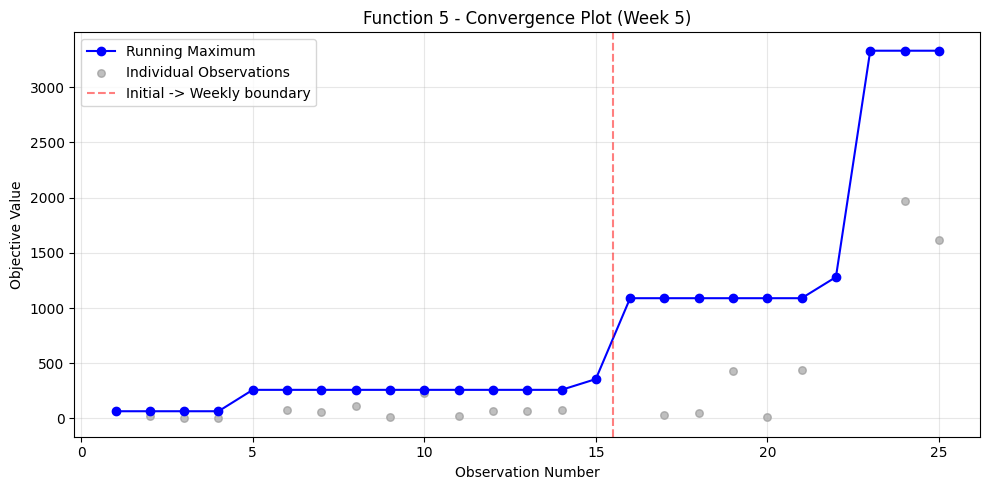

Best observed value: 3331.799696
Achieved at observation: 23


In [6]:
# Convergence plot
running_max = np.maximum.accumulate(y_w5)

plt.figure(figsize=(10, 5))
plt.plot(range(1, len(y_w5) + 1), running_max, 'b-o', markersize=6, label='Running Maximum')
plt.scatter(range(1, len(y_w5) + 1), y_w5, c='gray', alpha=0.5, s=30, label='Individual Observations')
plt.axvline(x=15.5, color='red', linestyle='--', alpha=0.5, label='Initial -> Weekly boundary')
plt.xlabel('Observation Number')
plt.ylabel('Objective Value')
plt.title('Function 5 - Convergence Plot (Week 5)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Best observed value: {y_w5.max():.6f}")
print(f"Achieved at observation: {y_w5.argmax() + 1}")

### Step 7: Format Submission Query

Format the proposed next sample point as `x1-x2-x3-x4` with 6 decimal places.

In [7]:
# Format submission query
def format_query(point):
    clamped = [max(0.0, min(1.0, x)) for x in point]
    return '-'.join([f'{x:.6f}' for x in clamped])

submission_query_w5 = format_query(next_point_w5)

print("=" * 60)
print("WEEK 5 SUBMISSION QUERY FOR FUNCTION 5")
print("=" * 60)
print(f"Surrogate: GBT Ensemble ({N_ENSEMBLE} models x {N_ESTIMATORS} trees)")
print(f"Acquisition: UCB (kappa={KAPPA})")
print(f"Next point: {next_point_w5}")
print(f"Ensemble mean: {mu[best_idx]:.6f}")
print(f"Ensemble std:  {sigma[best_idx]:.6f}")
print(f"")
print(f">>> SUBMISSION: {submission_query_w5}")
print("=" * 60)

WEEK 5 SUBMISSION QUERY FOR FUNCTION 5
Surrogate: GBT Ensemble (10 models x 250 trees)
Acquisition: UCB (kappa=2.5)
Next point: [0.88756004 0.17502455 0.97987267 0.98846706]
Ensemble mean: 2503.237079
Ensemble std:  202.666184

>>> SUBMISSION: 0.887560-0.175025-0.979873-0.988467


### Model Comparison

**Gradient Boosted Trees vs GP (Initial Section):**
- The GP model uses a Matern 5/2 kernel with Expected Improvement — well-suited for smooth objectives with calibrated posterior uncertainty.
- GBT builds an additive ensemble of shallow trees, learning complex non-linear mappings through sequential error correction.
- For f5's 4D problem with notably large output range (~0.1 to ~3332), GBT handles the extreme value range naturally without the numerical conditioning issues that GP may face.
- The 10-model ensemble provides diversity-based uncertainty: regions where models disagree (high std) indicate unexplored or complex areas.
- Key trade-off: GP uncertainty is principled (posterior), GBT uncertainty is empirical (ensemble diversity). GBT is more robust to extreme value ranges.

---

## Week 6 — Focus on Exploitation (κ = 0.5)

**Strategy Change**: Reduce UCB kappa from 2.5 → 0.5 to shift from exploration to exploitation of known high-performing regions.

**New for Week 6**: Output normalization via `StandardScaler` to improve GBT fit quality on the large-magnitude output range.

| Parameter | Week 5 | Week 6 | Rationale |
|-----------|--------|--------|-----------|
| κ (UCB)   | 2.5    | 0.5    | Exploitation focus |
| Output normalization | None | StandardScaler | Improve model fit |
| All other hyperparams | — | Unchanged | — |

### Step 1: Load Week 6 Cumulative Data

Load all 26 cumulative observations (6 initial + 4×5 weekly updates) and import `StandardScaler` for output normalization.

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler

# Load Week 6 cumulative data
X_w6 = np.load('../../data/f5/updated_inputs - Week 6.npy')
y_w6 = np.load('../../data/f5/updated_outputs - Week 6.npy')

print(f"Week 6 Data: {X_w6.shape[0]} samples, {X_w6.shape[1]} dimensions")
print(f"Input range:  [{X_w6.min():.6f}, {X_w6.max():.6f}]")
print(f"Output range: [{y_w6.min():.6f}, {y_w6.max():.6f}]")
print(f"Best observed value: {y_w6.max():.6f} at index {y_w6.argmax()}")
print(f"Best observed point: {X_w6[y_w6.argmax()]}")

Week 6 Data: 26 samples, 4 dimensions
Input range:  [0.000000, 1.000000]
Output range: [0.112940, 3331.799696]
Best observed value: 3331.799696 at index 22
Best observed point: [0.900721 0.       1.       1.      ]


### Step 2: GBT Ensemble Hyperparameters

**Hyperparameter Choices and Justifications:**

1. **n_estimators = 250**: Same as Week 5 — sufficient boosting rounds for 26 samples.
2. **max_depth = 4**: Same as Week 5 — shallow trees for boosting.
3. **learning_rate = 0.08**: Same as Week 5 — lower rate for better generalization.
4. **subsample = 0.8**: Same as Week 5 — stochastic gradient boosting.
5. **n_ensemble = 10**: Same as Week 5 — 10 independent models.
6. **UCB kappa = 0.5**: **Reduced from Week 5's κ=2.5** — strong exploitation focus.
7. **n_candidates = 20,000**: Same as Week 5.
8. **NEW — StandardScaler**: Normalize outputs before training to improve model fit.

In [9]:
# ── Week 6 GBT Ensemble Hyperparameters ──
N_ESTIMATORS = 250
MAX_DEPTH = 4
LEARNING_RATE = 0.08
SUBSAMPLE = 0.8
N_ENSEMBLE = 10
KAPPA = 0.5          # exploitation focus (reduced from 2.5)
N_CANDIDATES = 20_000

print("=== Week 6 GBT Ensemble Hyperparameters ===")
print(f"  n_estimators  = {N_ESTIMATORS}")
print(f"  max_depth     = {MAX_DEPTH}")
print(f"  learning_rate = {LEARNING_RATE}")
print(f"  subsample     = {SUBSAMPLE}")
print(f"  n_ensemble    = {N_ENSEMBLE}")
print(f"  kappa (UCB)   = {KAPPA}")
print(f"  n_candidates  = {N_CANDIDATES:,}")
print(f"  output norm   = StandardScaler (NEW)")

=== Week 6 GBT Ensemble Hyperparameters ===
  n_estimators  = 250
  max_depth     = 4
  learning_rate = 0.08
  subsample     = 0.8
  n_ensemble    = 10
  kappa (UCB)   = 0.5
  n_candidates  = 20,000
  output norm   = StandardScaler (NEW)


### Step 3: Train GBT Ensemble (with Output Normalization)

Fit `StandardScaler` on outputs, train 10 GBT models on scaled outputs. Display per-model R² (on scaled data) and normalization statistics.

In [10]:
# ── Output Normalization + Train GBT Ensemble (Week 6) ──

# Fit StandardScaler on outputs
y_scaler = StandardScaler().fit(y_w6.reshape(-1, 1))
y_scaled = y_scaler.transform(y_w6.reshape(-1, 1)).ravel()

print("=== Output Normalization Stats ===")
print(f"  y_w6 mean:   {y_scaler.mean_[0]:.6f}")
print(f"  y_w6 scale:  {y_scaler.scale_[0]:.6f}")
print(f"  y_scaled range: [{y_scaled.min():.6f}, {y_scaled.max():.6f}]")

# Train ensemble on normalized outputs
ensemble_w6 = []
for i in range(N_ENSEMBLE):
    gbt = GradientBoostingRegressor(
        n_estimators=N_ESTIMATORS,
        max_depth=MAX_DEPTH,
        learning_rate=LEARNING_RATE,
        subsample=SUBSAMPLE,
        random_state=42 + i
    )
    gbt.fit(X_w6, y_scaled)
    ensemble_w6.append(gbt)

# Display per-model R² on scaled data
print("\n=== GBT Ensemble Training R² (on scaled outputs) ===")
for i, gbt in enumerate(ensemble_w6):
    r2 = gbt.score(X_w6, y_scaled)
    print(f"  Model {i}: R² = {r2:.6f}")

# Feature importance (averaged across ensemble)
importances = np.mean([gbt.feature_importances_ for gbt in ensemble_w6], axis=0)
print("\n=== Average Feature Importance ===")
for j, imp in enumerate(importances):
    print(f"  x{j}: {imp:.4f}")

=== Output Normalization Stats ===
  y_w6 mean:   558.778909
  y_w6 scale:  902.725340
  y_scaled range: [-0.618866, 3.071832]

=== GBT Ensemble Training R² (on scaled outputs) ===
  Model 0: R² = 1.000000
  Model 1: R² = 1.000000
  Model 2: R² = 1.000000
  Model 3: R² = 1.000000
  Model 4: R² = 1.000000
  Model 5: R² = 1.000000
  Model 6: R² = 1.000000
  Model 7: R² = 1.000000
  Model 8: R² = 1.000000
  Model 9: R² = 1.000000

=== Average Feature Importance ===
  x0: 0.1738
  x1: 0.0184
  x2: 0.6100
  x3: 0.1978


### Step 4: UCB Acquisition (Exploitation Focus)

Generate 20,000 random candidates in [0, 1]⁴. Compute ensemble mean and std in **scaled** space, then inverse-transform to original scale before computing UCB = μ + κσ.

In [11]:
# ── UCB Acquisition with Inverse Transform (Week 6) ──
np.random.seed(42)
candidates_w6 = np.random.rand(N_CANDIDATES, X_w6.shape[1])

# Ensemble predictions in scaled space
preds_scaled = np.array([gbt.predict(candidates_w6) for gbt in ensemble_w6])
mu_scaled = preds_scaled.mean(axis=0)
sigma_scaled = preds_scaled.std(axis=0)

# Inverse transform to original scale
mu_w6 = y_scaler.inverse_transform(mu_scaled.reshape(-1, 1)).ravel()
sigma_w6 = sigma_scaled * y_scaler.scale_[0]  # std scales linearly

# UCB in original scale
ucb_w6 = mu_w6 + KAPPA * sigma_w6

best_idx = np.argmax(ucb_w6)
best_point_w6 = candidates_w6[best_idx]

print("=== UCB Acquisition Results (Week 6) ===")
print(f"  Best UCB     = {ucb_w6[best_idx]:.6f}")
print(f"  μ at best    = {mu_w6[best_idx]:.6f}")
print(f"  σ at best    = {sigma_w6[best_idx]:.6f}")
print(f"  Best point   = {best_point_w6}")
print(f"  Clipped to [0, 1]: {np.clip(best_point_w6, 0.0, 1.0)}")

=== UCB Acquisition Results (Week 6) ===
  Best UCB     = 2944.472140
  μ at best    = 2889.786285
  σ at best    = 109.371712
  Best point   = [0.98992314 0.27887085 0.92354276 0.99588628]
  Clipped to [0, 1]: [0.98992314 0.27887085 0.92354276 0.99588628]


### Step 5: Surrogate Visualization (2D Slice)

Project the 4D surrogate onto the two most important features, fixing the remaining dimensions at the best-point values. Three panels: predicted mean (original scale), ensemble std, and feature importance.

Top-2 important dims: x2, x3
Fixed dims: x0=0.9899, x1=0.2789


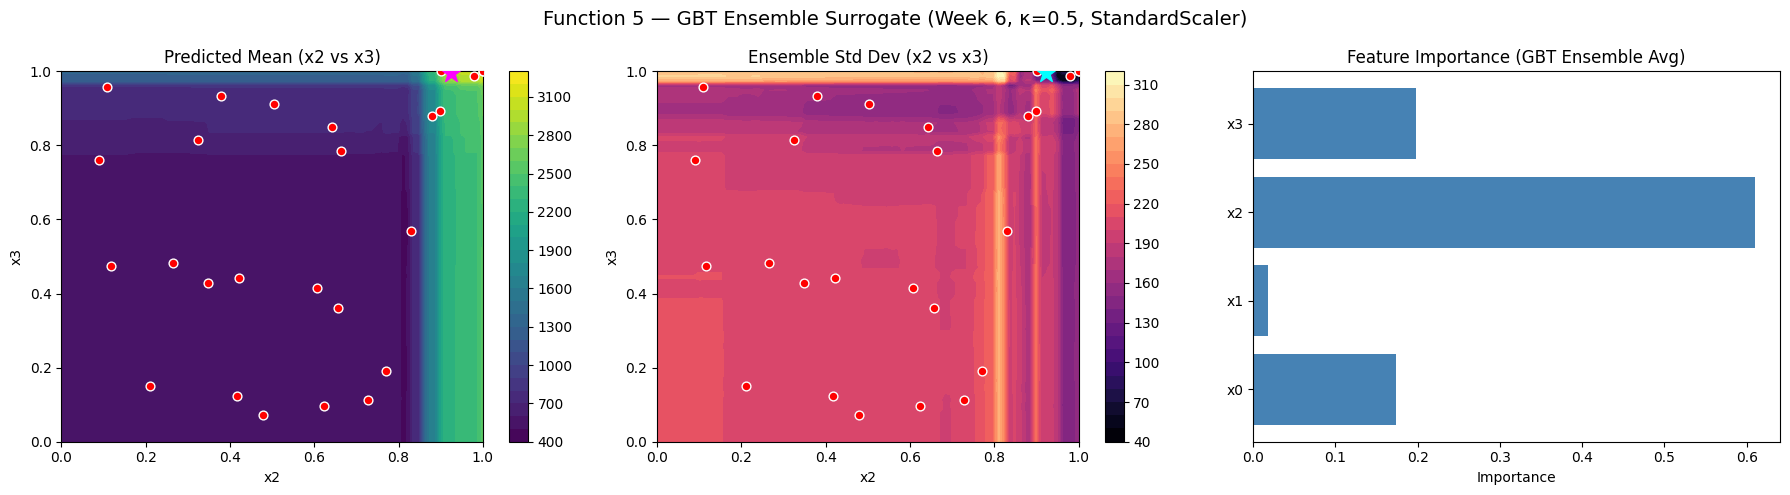

In [12]:
# ── Surrogate Visualization — 2D Slice (Week 6) ──

# Identify top-2 and bottom-2 features by importance
sorted_dims = np.argsort(importances)[::-1]
top2 = sorted_dims[:2]
fix_dims = sorted_dims[2:]

print(f"Top-2 important dims: x{top2[0]}, x{top2[1]}")
print(f"Fixed dims: " + ", ".join(f"x{d}={best_point_w6[d]:.4f}" for d in fix_dims))

# Build 2D grid over top-2 dims
grid_res = 80
g0 = np.linspace(0, 1, grid_res)
g1 = np.linspace(0, 1, grid_res)
G0, G1 = np.meshgrid(g0, g1)

grid_pts = np.tile(best_point_w6, (grid_res * grid_res, 1))
grid_pts[:, top2[0]] = G0.ravel()
grid_pts[:, top2[1]] = G1.ravel()

# Ensemble predictions on grid (inverse-transform to original scale)
grid_preds_scaled = np.array([gbt.predict(grid_pts) for gbt in ensemble_w6])
grid_mu_scaled = grid_preds_scaled.mean(axis=0)
grid_sigma_scaled = grid_preds_scaled.std(axis=0)
grid_mu = y_scaler.inverse_transform(grid_mu_scaled.reshape(-1, 1)).ravel().reshape(grid_res, grid_res)
grid_sigma = (grid_sigma_scaled * y_scaler.scale_[0]).reshape(grid_res, grid_res)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel 1: Mean (original scale)
c1 = axes[0].contourf(G0, G1, grid_mu, levels=30, cmap="viridis")
axes[0].scatter(X_w6[:, top2[0]], X_w6[:, top2[1]], c="red", edgecolors="white", s=40, zorder=5)
axes[0].scatter(best_point_w6[top2[0]], best_point_w6[top2[1]], c="magenta", marker="*", s=200, zorder=6)
axes[0].set_title(f"Predicted Mean (x{top2[0]} vs x{top2[1]})")
axes[0].set_xlabel(f"x{top2[0]}")
axes[0].set_ylabel(f"x{top2[1]}")
fig.colorbar(c1, ax=axes[0])

# Panel 2: Std
c2 = axes[1].contourf(G0, G1, grid_sigma, levels=30, cmap="magma")
axes[1].scatter(X_w6[:, top2[0]], X_w6[:, top2[1]], c="red", edgecolors="white", s=40, zorder=5)
axes[1].scatter(best_point_w6[top2[0]], best_point_w6[top2[1]], c="cyan", marker="*", s=200, zorder=6)
axes[1].set_title(f"Ensemble Std Dev (x{top2[0]} vs x{top2[1]})")
axes[1].set_xlabel(f"x{top2[0]}")
axes[1].set_ylabel(f"x{top2[1]}")
fig.colorbar(c2, ax=axes[1])

# Panel 3: Feature importance bar chart
axes[2].barh(range(X_w6.shape[1]), importances, color="steelblue")
axes[2].set_yticks(range(X_w6.shape[1]))
axes[2].set_yticklabels([f"x{j}" for j in range(X_w6.shape[1])])
axes[2].set_title("Feature Importance (GBT Ensemble Avg)")
axes[2].set_xlabel("Importance")

plt.suptitle("Function 5 — GBT Ensemble Surrogate (Week 6, κ=0.5, StandardScaler)", fontsize=14)
plt.tight_layout()
plt.show()

### Step 6: Convergence Plot

Running best (cumulative maximum of observed outputs) across all weeks, with a vertical line at the Week 5→6 boundary (sample 20.5 for Function 5's 26 observations: 6 initial + 4×5 weekly).

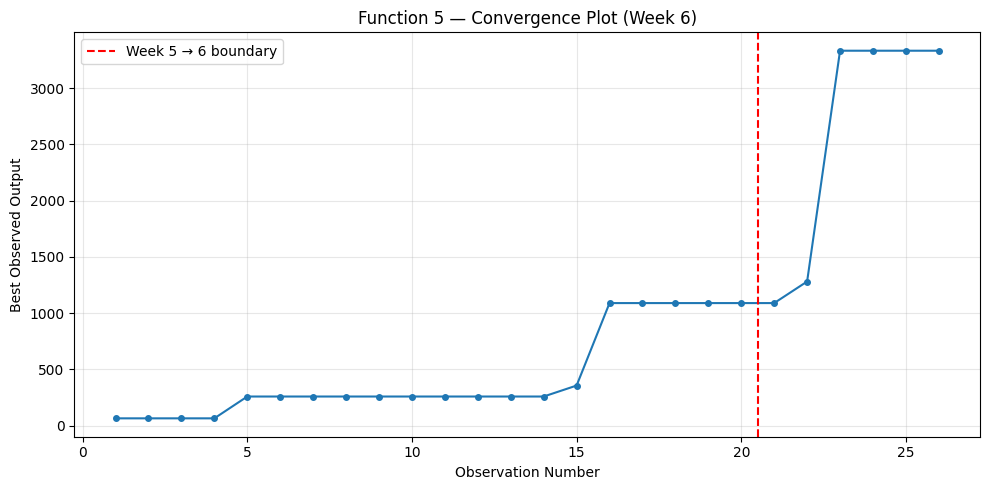

Running best at Week 5 end (sample 20): 1088.859618
Running best at Week 6 end (sample 26): 3331.799696


In [13]:
# ── Convergence Plot (Week 6) ──
running_best = np.maximum.accumulate(y_w6)

plt.figure(figsize=(10, 5))
plt.plot(range(1, len(y_w6) + 1), running_best, marker="o", markersize=4, linewidth=1.5)
plt.axvline(x=20.5, color="red", linestyle="--", label="Week 5 → 6 boundary")
plt.xlabel("Observation Number")
plt.ylabel("Best Observed Output")
plt.title("Function 5 — Convergence Plot (Week 6)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Running best at Week 5 end (sample 20): {running_best[19]:.6f}")
print(f"Running best at Week 6 end (sample {len(y_w6)}): {running_best[-1]:.6f}")

### Step 7: Submission Query

Format the best point as a dash-separated string with 6 decimal places, clipped to [0, 1].

In [14]:
# ── Submission Query (Week 6) ──
def format_query(point):
    clipped = np.clip(point, 0.0, 1.0)
    return "-".join(f"{v:.6f}" for v in clipped)

submission_query_w6 = format_query(best_point_w6)

print("=" * 50)
print("WEEK 6 SUBMISSION QUERY FOR FUNCTION 5")
print("=" * 50)
print(f"\n  {submission_query_w6}\n")
print("=" * 50)

# Validation
parts = submission_query_w6.split("-")
assert len(parts) == X_w6.shape[1], f"Expected {X_w6.shape[1]} dimensions, got {len(parts)}"
for p in parts:
    v = float(p)
    assert 0.0 <= v <= 1.0, f"Value {v} out of bounds"
print("✓ Submission format validated")

WEEK 6 SUBMISSION QUERY FOR FUNCTION 5

  0.989923-0.278871-0.923543-0.995886

✓ Submission format validated
